<div style="background: linear-gradient(to right, #6a11cb, #2575fc); padding: 20px; border-radius: 10px; text-align: center; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h1 style="color: white; margin: 0; font-size: 2.5em; font-weight: 700;">GAICo: Evaluating AI-Generated Audio</h1>
    <p style="color: #e0e0e0; margin-top: 10px; font-style: italic; font-size: 1.2em; text-align: center;">Why Specialized Audio Metrics are Essential</p>
</div>
<br>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ai4society/GenAIResultsComparator/blob/main/examples/example-audio.ipynb)

This notebook demonstrates how to use **GAICo's** specialized metrics for evaluating AI-generated audio. We will focus on a Text-to-Speech (TTS) use case to highlight why standard text-based metrics are unsuitable for audio tasks.

The goal is to show a side-by-side comparison:
-  **Audio Quality Evaluation:**
    - We will evaluate LLM-generated TTS audio using specialized metrics (`AudioSNR`, `AudioSpectrogramDistance`).
    - We will see how these metrics provide meaningful scores related to signal clarity and spectral similarity.

### Setup for Google Colab

If you are running this notebook in Google Colab, uncomment and run the following cell to install the `gaico` package with the necessary audio dependencies.

In [1]:
# !pip install 'gaico[audio]' -q

### Environment Setup & Imports

The cell below adjusts `sys.path` to find the `gaico` module if you are running this notebook locally from the `examples/` directory without having installed the package.

In [1]:
import os
import sys

# Adjust sys.path to find the gaico module if run from examples directory
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, os.pardir))

if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Added project root to sys.path: {project_root}")

In [2]:
import pandas as pd
from pathlib import Path
from IPython.display import Audio, display

# Import the Experiment class for streamlined comparison
from gaico import Experiment

---
## Evaluating Text-to-Speech (TTS) Outputs

In this section, we will evaluate the quality of audio files generated by different TTS models. An ideal TTS output should sound clear, have minimal background noise, and be spectrally similar to a high-quality reference.

We will compare two types of metrics:

- **Specialized Audio Metrics:**
  - **`AudioSNR` (Signal-to-Noise Ratio):** Measures the clarity of the speech signal against background noise. Higher is better.
  - **`AudioSpectrogramDistance`:** Compares the frequency content and temporal structure of two audio files. Higher indicates more similarity.

### Data Loading and Provenance

The audio files used in this example were pre-generated using various TTS models. The reference audio is a high-quality rendering, while the others represent outputs from different models of varying quality.

**The process for generating this data can be found in the advanced audio notebook: `examples/basic-examples/example-audio_data.ipynb`**.

In [3]:
# 1. Define paths to the AI-generated audio files
audio_dir = Path("data/audio/audio_samples")

# A dictionary of TTS model outputs
tts_outputs = {
    "Google TTS": str(audio_dir / "gtts_output.mp3"),
    "Edge TTS (Guy)": str(audio_dir / "edge_tts_guy.mp3"),
    "Synthetic TTS (Poor)": str(audio_dir / "synthetic_poor_tts.wav"),
}

# Use a high-quality TTS output as the reference
reference_audio = str(audio_dir / "edge_tts_aria.mp3")

print("Reference Audio Path:", reference_audio)
print("\nLLM-Generated Audio Paths:")
for model, path in tts_outputs.items():
    print(f"- {model}: {path}")

Reference Audio Path: data/audio/audio_samples/edge_tts_aria.mp3

LLM-Generated Audio Paths:
- Google TTS: data/audio/audio_samples/gtts_output.mp3
- Edge TTS (Guy): data/audio/audio_samples/edge_tts_guy.mp3
- Synthetic TTS (Poor): data/audio/audio_samples/synthetic_poor_tts.wav


### Listen to the Audio Samples

Before scoring, let us listen to the reference and one of the generated samples to get a subjective sense of their quality.

*(Note: To hear the audio samples, you must run this notebook in a local environment.)*

In [4]:
print("Reference Audio (Edge TTS - Aria):")
display(Audio(reference_audio))

print("\nGenerated Sample (Google TTS):")
display(Audio(tts_outputs["Google TTS"]))

print("\nGenerated Sample (Edge TTS - Guy):")
display(Audio(tts_outputs["Edge TTS (Guy)"]))

print("\nGenerated Sample (Synthetic TTS - Poor):")
display(Audio(tts_outputs["Synthetic TTS (Poor)"]))

Reference Audio (Edge TTS - Aria):



Generated Sample (Google TTS):



Generated Sample (Edge TTS - Guy):



Generated Sample (Synthetic TTS - Poor):


### Running the Experiment

Now, we will use the `Experiment` class to compare the generated audio files against the reference using our selected metrics. The results will be saved to a CSV file in the appropriate data directory.

/Users/nitingupta/usc/ai4s/libraries/GenAIResultsComparator/gaico/metrics/audio/audio.py:369: UserWarning: Sample rates differ (generated: 22050, reference: 24000). Resampling generated audio to match reference rate 24000 Hz.
  warnings.warn(
/Users/nitingupta/usc/ai4s/libraries/GenAIResultsComparator/gaico/metrics/audio/audio.py:520: UserWarning: Sample rates differ (generated: 22050, reference: 24000). Resampling generated audio to match reference rate 24000 Hz.
  warnings.warn(


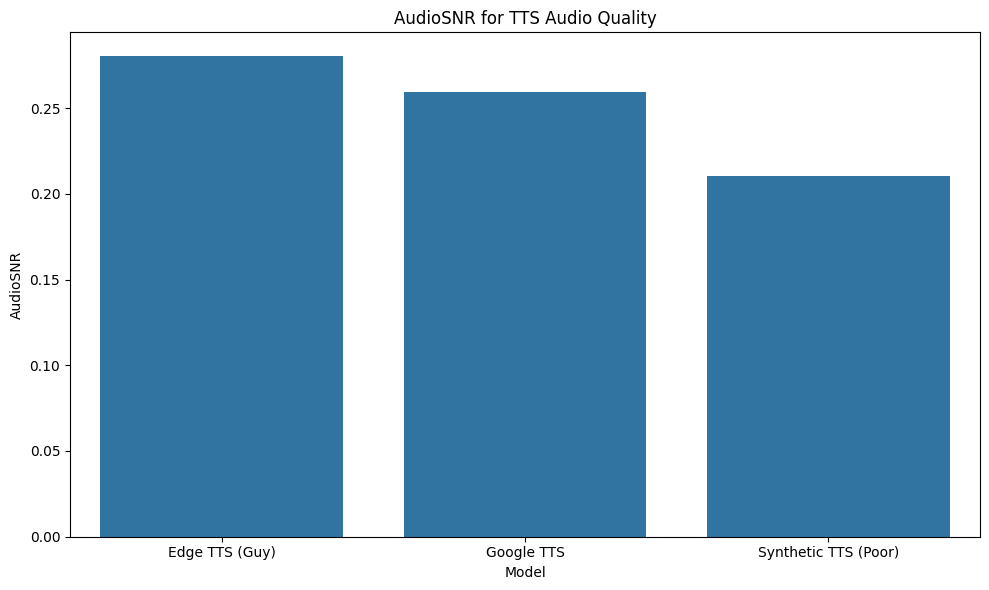

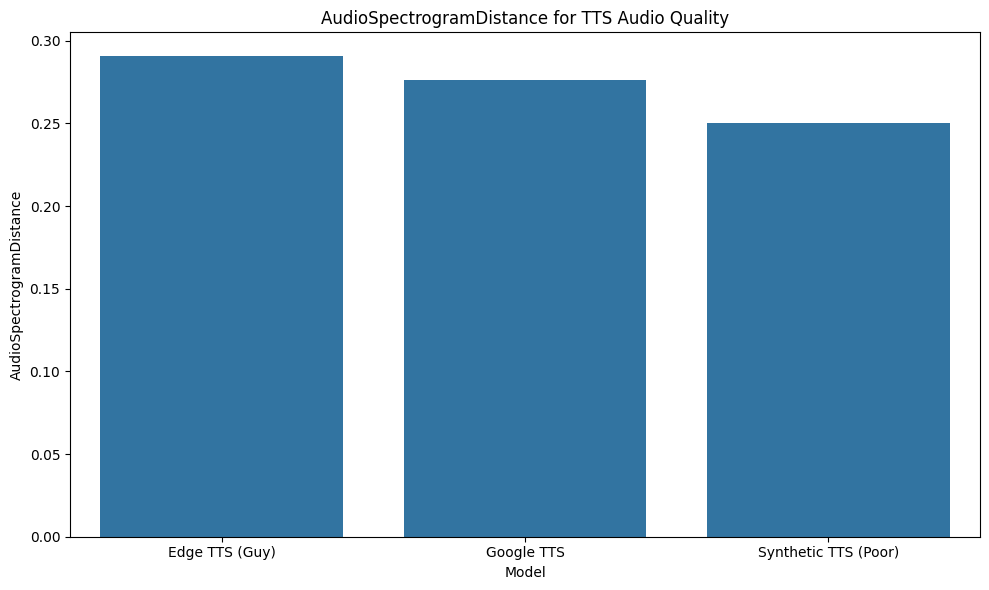

CSV report generated at: data/audio/audio_example_tts_evaluation_results.csv

Results saved to: data/audio/audio_example_tts_evaluation_results.csv

DataFrame of Audio Metric Scores:
metric_name           AudioSNR  AudioSpectrogramDistance
model_name                                              
Edge TTS (Guy)          0.2802                    0.2905
Google TTS              0.2596                    0.2760
Synthetic TTS (Poor)    0.2106                    0.2499


In [5]:
# 2. Initialize and run the Experiment
audio_exp = Experiment(llm_responses=tts_outputs, reference_answer=reference_audio)

# Define the output path for the results
output_dir = Path("data/audio")
output_dir.mkdir(exist_ok=True)
csv_path = output_dir / "audio_example_tts_evaluation_results.csv"

# 3. Compare using both audio and a standard text metric
# Note: We expect the text metric to fail or give a meaningless score.
results_df = audio_exp.compare(
    metrics=["AudioSNR", "AudioSpectrogramDistance"],
    plot=True,
    output_csv_path=csv_path,
    plot_title_suffix="for TTS Audio Quality",
)

print(f"\nResults saved to: {csv_path}")
print("\nDataFrame of Audio Metric Scores:")

# Displaying with higher precision for clarity
with pd.option_context("display.precision", 4):
    print(results_df.pivot(index="model_name", columns="metric_name", values="score"))

### Analysis of Results

The bar plot and the DataFrame reveal important insights about audio evaluation metrics:

**Score Interpretation:**
All scores are relatively low (0.21-0.29 range), which is expected when comparing different TTS systems against a reference. This happens because:

1. **Different Voice Characteristics**: Each TTS system has its own voice model. Even high-quality systems like Edge TTS (Guy) and Google TTS have different speakers, timbres, and prosody compared to the reference (Edge TTS Aria).

2. **AudioSNR Scores (0.21-0.28)**: 
   - These low scores don't indicate poor quality, but rather that the waveforms are significantly different from the reference
   - SNR treats any deviation from the reference as "noise", including legitimate voice differences
   - Edge TTS (Guy) scores highest (0.28), followed by Google TTS (0.26), and Synthetic Poor TTS lowest (0.21)

3. **AudioSpectrogramDistance Scores (0.25-0.29)**:
   - Similarly low scores reflect different spectral characteristics between voices
   - The ranking matches AudioSNR: Edge TTS (Guy) > Google TTS > Synthetic Poor TTS
   - Even a 0.04 difference (0.29 vs 0.25) represents meaningful quality differences in audio

**Key Insight**: When using a different voice as reference, expect lower absolute scores. The **relative ranking** is what matters - the metrics correctly identify that Edge TTS (Guy) is closest to the reference quality, while the synthetic poor quality TTS is furthest.

**For more meaningful absolute scores**, compare:
- Same TTS system with different settings
- Noisy vs clean versions of the same recording
- Or use human evaluation scores for calibration

---

### Final Conclusion

This notebook has demonstrated how to leverage GAICo's specialized audio metrics to perform a meaningful evaluation of TTS outputs. By choosing the right metric for the job, you can gain accurate insights into the quality and characteristics of your generated audio, a task where standard text metrics fail completely.